# Value Stream Simulator Tutorial

By the end of this tutorial you will have an understanding of:
* Definition of value stream 
* Building blocks of a simulation
* Creating a simulation
* Interpreting the results of a simulation
* Minimizing loss


## Concepts

### Time
Simulations utilize an arbitrary time scale, starting at t=0.   Time is used when calculating depreciation and comparing loss between different models of delivery.

### Task
A Task is the unit of delivery.  Each Task is assigned an initial value that depreciates until it's delivered.  The depreciated values of tasks are used to measure a value stream's effectiveness.

The _story_points_ attribute is a relative measure of how much effort is required to develop the task.

In [1]:
from value_stream import Task

# Create a simple task and retrieve its value
task = Task(initial_value=1, story_points=2)
task.value()

1

Without arguments, _task.value()_ returns the _initial_value_ of the task.   To return a task's depreciated value, provide an argument to the _time_ parameter:

In [2]:
print(task.depreciation_rate)

# show how a task depreciates over 4 time periods

for t in range(4):
    print(f"t({t}): {task.value(t)}")

0.005
t(0): 1
t(1): 0.995
t(2): 0.990025
t(3): 0.985074875


Depreciation is calculated relative to the _creation_time_ of the task. The depreciation rate decreases over time, approaching but never reaching 0.

### Developer

Development of a Task is simulated by a _Developer_:


In [3]:
from value_stream.resources import Developer

developer = Developer()

print(developer.efficiency)

1.0


The _efficiency_ attribute affects how much time a developer requires to develop a task:

* Development Time = (1/Developer.efficiency) * Task.story_points

By default, developers are initialized with an _efficiency_ of 1.0, which 1 unit of time is required to complete a task with 1.0 story_points.

In [4]:
# Senior developer completes tasks 3x faster than a junior developer
senior_dev = Developer(efficiency=1.5)
junior_dev = Developer(efficiency=.5)

To simulate the software development lifecycle (SDLC), Value Stream Simulator utilizes python's [SimPy](https://simpy.readthedocs.io/en/latest/) library.

The next few sections expose some internals in order to introduce additional concepts, but don't worry, by the end of this tutorial you will learn how execute multiple simulations with only a few lines of code.

This next example shows the effect developer efficiency has on development time, by simulating a task being developed by senior and junior developers.

In [5]:
import copy
from simpy import Environment
from value_stream import WorkflowState, WorkflowStateName

# SimPy.Environment coordinates the events of a simulation
env = Environment()

# Completed tasks are collected in a SimPy.Store
developed_tasks = WorkflowState(env, WorkflowStateName.DEV_COMPLETE)

# Compare outcomes when 2 developers work on identical tasks
# Using task.reset() to create distinct but identical task instances
env.process(senior_dev.operate(env, [task.reset()], developed_tasks))
env.process(junior_dev.operate(env, [task.reset()], developed_tasks))
env.run()

# Print the time each task was in the 'DEVELOPMENT' state:
for developed_task in developed_tasks.items:
    print(developed_task.history.duration(WorkflowStateName.DEVELOPMENT))

1.3333333333333333
4.0


This shows the task was completed by the senior developer (_efficiency_=1.5) approximately 3 times faster than the junior developer (_effiiency_=0.5)

While this may at first seem like a lot of overheard for a simple calculation, it allows for future addition of other factors that can influence development time, such as development environment friction, interruptions, onboarding effort, etc. 


### Task Workflow and Task History
In the previous example, the following code is used to get the amount of time spent on developing a task:

* _developed_task.history.duration(WorkflowStateName.DEVELOPMENT)_

Throughout a simulation, tasks proceed through a workflow, as defined by WorkflowStateName:


In [6]:
print([state.value for state in WorkflowStateName])

['pending', 'development', 'dev_complete', 'qa_testing', 'qa_complete', 'deployment', 'delivery']


Throughout its lifecycle, a task is moved between workflow states by a resource. For example, a Developer removes tasks from the _pending_ state, processes them in the _development_ state, then places them in the _dev_complete_ state when finished.

The _task.history_ object tracks these events as a time series.

Let's take a closer look at first task from the previous example:


In [7]:
task = developed_tasks.items[0]

for e in task.history.events:
    print(vars(e))

{'event': <WorkflowStateName.DEVELOPMENT: 'development'>, 'event_type': <EventType.START: 'start'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
{'event': <WorkflowStateName.DEVELOPMENT: 'development'>, 'event_type': <EventType.END: 'end'>, 'time': 1.3333333333333333, 'status': <EventStatus.SUCCESS: 'success'>}
{'event': <WorkflowStateName.DEV_COMPLETE: 'dev_complete'>, 'event_type': <EventType.START: 'start'>, 'time': 1.3333333333333333, 'status': <EventStatus.SUCCESS: 'success'>}


_events_ is a list of _TaskEvent_ objects, each with the following attributes"
* _event_: _WorkflowStateName_ as described previously.  In this example, _development_.
* _event_type_: Usually _start_ or _end_, but may also be _terminal_ to represent a final state of the workflow
* _time_ : Simulation time of the event
* _status_ : Outcome of the event, either 'success' or 'failure'

Calling _task.history.duration() with a WorkflowStateName as an argument, will return the elapsed time the task spent in that state.

Recalling from the last example:

In [8]:
task.history.duration(WorkflowStateName.DEVELOPMENT)

1.3333333333333333

### Developer Manager

In [Developer](#developer), the example manually handled the creation and assignment of developers to tasks.  In practice, developers are a limited resource and are assigned to tasks from a pool of available developers.  To simulate this, use Manager:

In [9]:
from value_stream.resources import ResourceOperator

# Reset the environment
env = Environment()


# Helper function to create a collection of developed tasks
def create_developed_tasks(env: Environment):

    tasks = [Task(task_id="Task 1", initial_value=1, story_points=1),
             Task(task_id="Task 2", initial_value=1, story_points=2),
             Task(task_id="Task 3", initial_value=1, story_points=.5)]

    pending_tasks = WorkflowState(env, WorkflowStateName.PENDING)

    for t in tasks:
        pending_tasks.put(t)

    # Create a team of 2 developers
    team = ResourceOperator(env, [senior_dev, junior_dev])

    developed_tasks = WorkflowState(env, WorkflowStateName.DEV_COMPLETE)

    # DeveloperTeam.start assigns developers to tasks
    # until all pending_tasks are in developed_tasks
    team.start(pending_tasks, developed_tasks)

    return developed_tasks


tasks = create_developed_tasks(env)
env.run()

# For each task, print a tuple of (start,end) times for the development workflow state
for task in tasks.items:
    print(f"{task.task_id}: {task.history.event_times(WorkflowStateName.DEVELOPMENT)}")

Task 1: (0, 0.6666666666666666)
Task 3: (0.6666666666666666, 1.0)
Task 2: (0, 4.0)


The example above shows Task 1 and Task 2 starting at the same time (t=0 )and Task 3 starting after the developer assigned to Task 1 completed at t=0.667.

Tasks are assigned to the first available developer, future versions may explore more intelligent developer assignment strategies.

### Toolchain

Toolchain simulates the post-development portion of a the value stream by processing between the _dev_complete_, _deployment_ and _delivery_ workflow states.


A Toolchain object is defined by the following attributes:

* _deployment_duration_ : Fixed time cost per deployment, simulating time required to build/test/deploy plus any compliance and change management approvals.
* _deployment_cadence_ : If 0, deployments occur on-demand (continuous delivery).  If > 0, defines the schedule for batch deployments. (release train)
* _concurrency_ : Defines the number of deployments that can occur simultaneously.  Used to simulate cases where deployment servers are not elastic.


In [10]:
from value_stream import TerminalWorkflowState, WorkflowStateName
from value_stream.resources import ResourceOperator
from value_stream.resources import Toolchain

env = Environment()

# Helper function for later reuse


def example_delivery(cadence: int):
    # Prefill some tasks that are ready for delivery
    developed_tasks = create_developed_tasks(env)

    # Simulate continuous delivery
    toolchain = ResourceOperator(env=env,
                                 resources=Toolchain.create_pool(
                                     limit=1, deployment_duration=.25),
                                 cadence=cadence)

    deployed_tasks = TerminalWorkflowState(env, WorkflowStateName.DELIVERY)

    toolchain.start(source=developed_tasks, target=deployed_tasks)
    env.run(until=5)

    return deployed_tasks


deployed_tasks = example_delivery(0)
for deployed_task in deployed_tasks.items:
    print(f"{deployed_task.task_id}:")
    for event in deployed_task.history.events:
        print(f"\t{vars(event)}")

Task 1:
	{'event': <WorkflowStateName.PENDING: 'pending'>, 'event_type': <EventType.START: 'start'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.PENDING: 'pending'>, 'event_type': <EventType.END: 'end'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEVELOPMENT: 'development'>, 'event_type': <EventType.START: 'start'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEVELOPMENT: 'development'>, 'event_type': <EventType.END: 'end'>, 'time': 0.6666666666666666, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEV_COMPLETE: 'dev_complete'>, 'event_type': <EventType.START: 'start'>, 'time': 0.6666666666666666, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEV_COMPLETE: 'dev_complete'>, 'event_type': <EventType.END: 'end'>, 'time': 0.6666666666666666, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName

In the example above, note how the start time of each deployment state event corresponds to the end time of the development state, reflecting on-demand, continuous delivery.  

Also note how the 'delivery' state is of type 'terminal', reflecting its nature as a milestone.

#### Cadence

Let's replay the previous example but with cadence = 1:

In [11]:
# Re-populate dev_complete_tasks
env = Environment()

deployed_tasks = example_delivery(1)
for deployed_task in deployed_tasks.items:
    print(f"{deployed_task.task_id}:")
    for event in deployed_task.history.events:
        print(f"\t{vars(event)}")

Task 1:
	{'event': <WorkflowStateName.PENDING: 'pending'>, 'event_type': <EventType.START: 'start'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.PENDING: 'pending'>, 'event_type': <EventType.END: 'end'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEVELOPMENT: 'development'>, 'event_type': <EventType.START: 'start'>, 'time': 0, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEVELOPMENT: 'development'>, 'event_type': <EventType.END: 'end'>, 'time': 0.6666666666666666, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEV_COMPLETE: 'dev_complete'>, 'event_type': <EventType.START: 'start'>, 'time': 0.6666666666666666, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEV_COMPLETE: 'dev_complete'>, 'event_type': <EventType.END: 'end'>, 'time': 1, 'status': <EventStatus.SUCCESS: 'success'>}
	{'event': <WorkflowStateName.DEPLOYMENT: 'dep

In this example, notice how the deployments of Task 1 and Task 3 were batched together, both starting at time=1.  This is because both tasks ended development with time <=1.  Meanshile, Task 2 completed development at t=4.0, and therefore was included in the t=4 batch. 

### Loss
Loss is the percentage difference between a task's initial and delivered values.   

In [12]:
from value_stream import WorkflowStateName
for cadence in range(0, 2):

    env = Environment()

    deployed_tasks = example_delivery(cadence)

    for deployed_task in deployed_tasks.items:
        print(
            f"Cadence ({cadence}): {deployed_task.task_id}: {deployed_task.loss} "
            f"({deployed_task.history.event_times(WorkflowStateName.DELIVERY)[0]})")

Cadence (0): Task 1: -0.00458428992300286 (0.9166666666666666)
Cadence (0): Task 3: -0.006246088856476928 (1.25)
Cadence (0): Task 2: -0.021077990199532826 (4.25)
Cadence (1): Task 1: -0.006246088856476928 (1.25)
Cadence (1): Task 3: -0.011214858412194495 (2.25)


The output above shows the loss of each task, which is the value of the task at the time of delivery  Notice how the loss for Task 1 is smaller when cadence==0.  This is because when cadence==1, Task 1 needed to wait until t=1 for its delivery, resulting in a slightly longer period of depreciation.

The primary objective of the Value Stream Simulator is to minimize loss, which is accomplished by reducing delays during the delivery of tasks. 

## Simulation
The previous section introduced foundational concepts for the Value Stream Simulator.   The examples provided were intentionally simplistic - calculating the delivery time and value of a task could be done with basic arithmetic.

An objective of the Value Stream Simulator is to optimize the software delivery process and reduce loss.  It accomplishes this by simulating the delivery of a set of tasks using different parameters.  The simulation results are then compared to understand which parameters have the greatest impact on reducing loss.

The following sections cover the creation of Models, which encapsulate development and toolchain parameters, and Simulations, which simulate the delivery of tasks using model parameters.



### Models

A Model describes a developer team and toolchain attributes.

In [13]:
from value_stream import Model
from value_stream.resources import QATester, Toolchain

# Model a development team with 3 junior developers
model_junior = Model(developer_team=[junior_dev, junior_dev, junior_dev],
                     deployment_cadence=1,
                     qa_testers=QATester.create_pool(limit=1),
                     toolchain_pool=Toolchain.create_pool(limit=1, deployment_duration=.25))

# Model team with 2 senior developers
model_senior = Model(developer_team=[senior_dev, senior_dev],
                     deployment_cadence=1,
                     qa_testers=QATester.create_pool(limit=1),
                     toolchain_pool=Toolchain.create_pool(limit=1, deployment_duration=.25))

Let's see how these models compare by simulating the delivery of 3 tasks

In [14]:
from value_stream import Simulation


pending_tasks = [Task(task_id="1", initial_value=1, story_points=1),
                 Task(task_id="2", initial_value=1, story_points=2),
                 Task(task_id="3", initial_value=1, story_points=.5)]

simulation = Simulation()

# Executes 2 simulations - one per model
simulation_results = simulation.execute(models=[model_junior, model_senior],
                                        tasks=pending_tasks)

print(len(simulation_results))

6


_simulation.execute_ returns a list of _SimulationResult_ objects, one for each (Model,Task) combination executed in the simulation.  SimulationResult encapsulates a Model, a Task, and the TaskEvents generated for the task for the Model.

_SimulationResult_ also has convenience methods that summarize the delivered value and loss.

In [15]:
for r in simulation_results:
    print("Team Size:", r.model.team_size)
    print("Delivered Value:", r.task.delivered_value)
    print(f"Loss: {r.task.loss:.2%}\n")

Team Size: 3
Delivered Value: 0.9887851415878055
Loss: -1.12%

Team Size: 3
Delivered Value: 0.9838412158798665
Loss: -1.62%

Team Size: 3
Delivered Value: 0.9740273997514648
Loss: -2.60%

Team Size: 2
Delivered Value: 0.9937539111435231
Loss: -0.62%

Team Size: 2
Delivered Value: 0.9887851415878055
Loss: -1.12%

Team Size: 2
Delivered Value: 0.9887851415878055
Loss: -1.12%



The sample results above show the team of 3 junior developers (efficiency=0.5) delivered less total value than the team of 2 senior developers (efficiency==1.5).

Later, this tutorial will introduce techniques for visualizing and analyzing simulation results.   Before that, let's cover some utilities that help build more meaningful simulations.

### Building Simulations
As described above, simulations execute the delivery of a set of tasks using parameters defined in one or more models.   This section introduces utilities that help generate a range of models that result in more meaningful analysis.

#### Creating Teams with DeveloperFactory
DeveloperFactory is used to create a set of Developer objects with specified efficiency characteristics.


In [16]:
from value_stream.utils import DeveloperFactory, generator_utils
import numpy as np

# Ensures consistent tutorial results
np.random.seed(42)


# Create 5 developers all with an efficiency of 0.5
dev_factory = DeveloperFactory()
junior_team = dev_factory.create(3, efficiency=0.5)

for dev in junior_team:
    print(vars(dev))

# Create 6 developers with efficiencies ranging from 0.5 to 1.5
dev_factory = DeveloperFactory()

varied_team = dev_factory.create(
    6, efficiency=generator_utils.uniform(.5, 1.5)
)
print('\n')
for dev in varied_team:
    print(vars(dev))

{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 0', 'efficiency': 0.5}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 1', 'efficiency': 0.5}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 2', 'efficiency': 0.5}


{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 0', 'efficiency': 1.3831041842296878}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 1', 'efficiency': 0.5507629763203294}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 2', 'efficiency': 1.4773396481925616}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 3', 'efficiency': 1.423111702087828}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: 'development'>, 'name': 'Developer 4', 'efficiency': 0.6898221555366744}
{'workflow_state': <WorkflowStateName.DEVELOPMENT: '

#### ModelFactory
ModelFactory allows for the creation of Model objects that differ along two vectors: development team and toolchain cadence.

This allows for analysis on how each combination of developer team and cadence impacts loss.

In the example below, 20 models are created.  2 developer teams * 10 toolchains, each toolchain with a difference cadence from 0-9

In [17]:
from value_stream.utils import ModelFactory
from value_stream.resources import QATester, Toolchain

model_factory = ModelFactory()

models = model_factory.create(
    teams=[junior_team, varied_team],
    deployment_cadences=range(0, 10),
    qa_testers=QATester.create_pool(limit=1),
    toolchain_pool=Toolchain.create_pool(limit=1, deployment_duration=.5))

# 2 teams * 10 cadences * 3 tasks
print(len(models))

20


Running a simulation using each of these models against the same set of tasks produces 60 SimulationResult objects, one per (model,task):

In [18]:
simulation = Simulation()
results = simulation.execute(tasks=pending_tasks, models=models)

print(len(results))

60


### Analyzing Simulation Results

ResultViewer provides methods for visualizing the outcome of simulations.  It also provides access to raw data, enabling custom analysis and visualization.


In [19]:
from value_stream.utils import ResultViewer

viewer = ResultViewer(results)

Use the _df_ attribute to access the result as a pandas DataFrame.  



* _history.dev_wait_ : Time waiting for development to begin.  (_history.dev_start_t_ - _creation_t_)
* _history.dev_t_ : Time spent under development. (_history.dev_end_t_ - _history.dev_start_t_)
* _history.delivery_wait_ : Time spent waiting for deployment to begin. (_history.delivery_start_t - _history.dev_end_t_)
* _history.delivery_t_ : Time spent in deployment. (_history.delivery_end_t_ - _history.delivery_start_t_)

In [20]:
# Show the columns
viewer.df

event  \
model.deployment_cadence model.team_size task.task_id                 
0                        3               1                  pending   
                                         1                  pending   
                                         1              development   
                                         1              development   
                                         1             dev_complete   
...                                                             ...   
9                        6               3              qa_complete   
                                         3              qa_complete   
                                         3               deployment   
                                         3               deployment   
                                         3                 delivery   

                                                      event_type      time  \
model.deployment_cadence model.team_size task.task_id                        
0                        3               1                 start  0.000000   
                                         1                   end  0.000000   
                                         1                 start  0.000000   
                                         1                   end  2.000000   
                                         1                 start  2.000000   
...                                                          ...       ...   
9                        6               3                 start  0.388446   
                                         3                   end  9.000000   
                                         3                 start  9.000000   
                                         3                   end  9.500000   
                                         3              terminal  9.500000   

                                                        status  \
model.deployment_cadence model.team_size task.task_id            
0                        3               1             success   
                                         1             success   
                                         1             success   
                                         1             success   
                                         1             success   
...                                                        ...   
9                        6               3             success   
                                         3             success   
                                         3             success   
                                         3             success   
                                         3             success   

                                                      model.toolchain_concurrency  \
model.deployment_cadence model.team_size task.task_id                               
0                        3               1                                    NaN   
                                         1                                    NaN   
                                         1                                    NaN   
                                         1                                    NaN   
                                         1                                    NaN   
...                                                                           ...   
9                        6               3                                    NaN   
                                         3                                    NaN   
                                         3                                    NaN   
                                         3                                    NaN   
                                         3                                    NaN   

                                                      task.loss  \
model.deployment_cadence model.team_size task.task_id             
0                       

#### Plotting Results

ResultViewer also offers a set of visualizations based on Matplotlib:

As mentioned previously, a Simulation delivers a set of Task objects based on the attributes of a Model.  These include toolchain parameters (specifically, deployment cadence), and one or more development teams.   The plots provided by ResultViewer aim to identify factors that affect loss (and delivered value.)

##### Loss vs. Cadence
Calling _loss_vs_cadence_ shows the impact of deployment cadence on loss.  It contains a series for each team size included in the simulation.  When the optional _team_samples_ parameter is provided, it limits the number of series to an even distribution of team sizes between the minimum and maximum, inclusive.


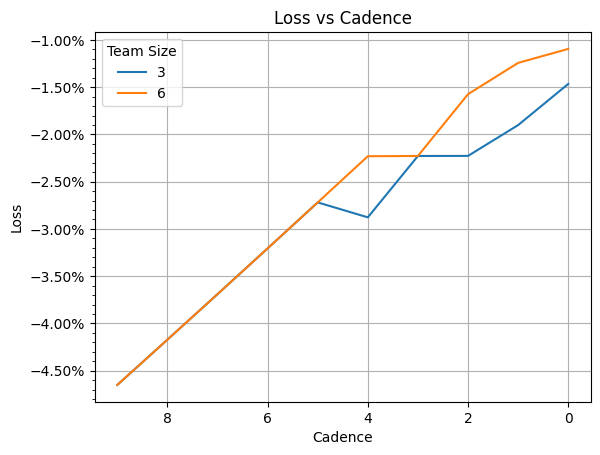

In [21]:
viewer.loss_vs_cadence()

This example shows loss decreasing as cadence decreases (which is an increase in delivery frequency). This is the result of reducing the amount of time a 'dev-complete' task waits for the next deployment window.  

The divergence in the series suggests the smaller team of developers (each with a 0.5 efficiency) isn't able to take advantage of higher delivery cadences due to more time being required to develop the tasks.

##### Time Allocation by Cadence
To get a view of where time is being spent, use _time_alloc_vs_cadence_.  This plots a grid of pie charts providing a breakdown of how time was spent for a sample of delivery cadences from the simulation.  Use the optional _nrows_ and _ncols_ parameters (defaults are 2x3) to control the number of samples.

The results for each cadence are averaged across all team sizes.

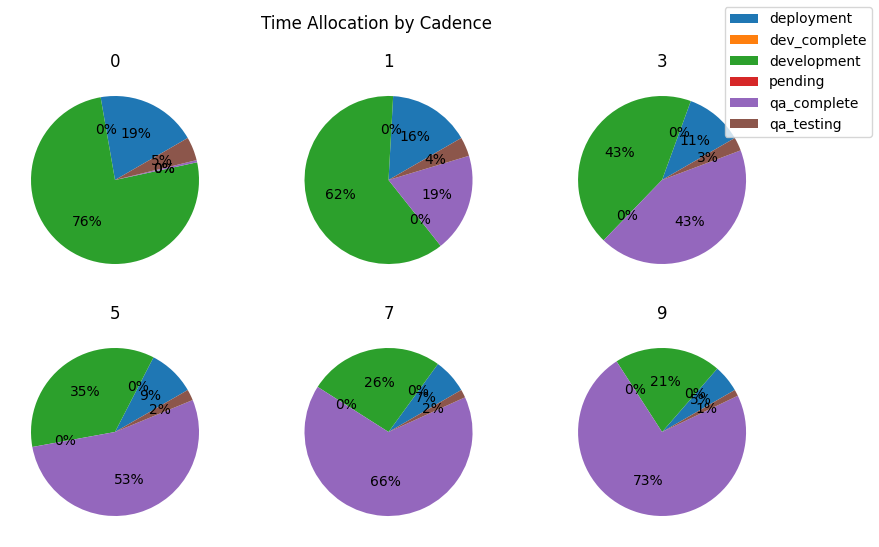

In [22]:
viewer.time_alloc_vs_cadence()

This example shows how the decrease in cadence results in delivery being more dependent on development time as tasks don't need to wait as long for the next deployment to occur.

##### Delivery Timeline

Use _delivery_timeline_ for a task-centric view of delivery.  The _cadence_ and _team_size_ parameters choose the result from the simulation to analyze.

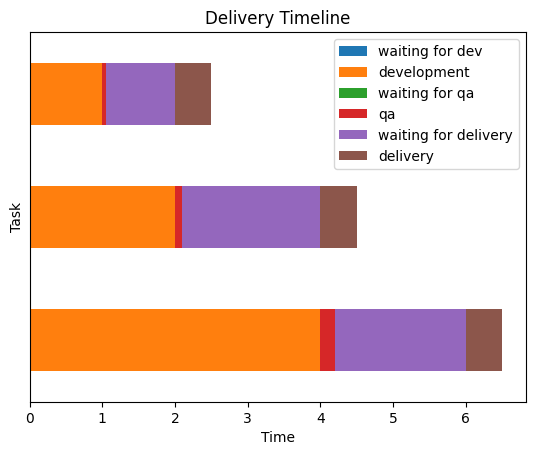

In [23]:
viewer.delivery_timeline(cadence=2, team_size=3)

This example looks at how the team of 3 developers delivered the 3 tasks in the simulation, where delivery happens every 2t.  Because there is sufficient developer capacity, not tasks needed to wait for a developer to become available.  The first task was completed before the next deployment window (at t=2), so it had to wait (increasing the overall loss.)   The other two tasks were completed right at a deployment window.

Note that the task id is not displayed.  This can otherwise result in visual clutter when there are a large number of tasks to present.

##### Delivered Value vs Time
_delivered_value_vs_time_ plots a timeline of value delivery for a specified cadence.  When the optional _team_samples_ parameter is provided, it limits the number of series to an even distribution of team sizes between the minimum and maximum, inclusive.

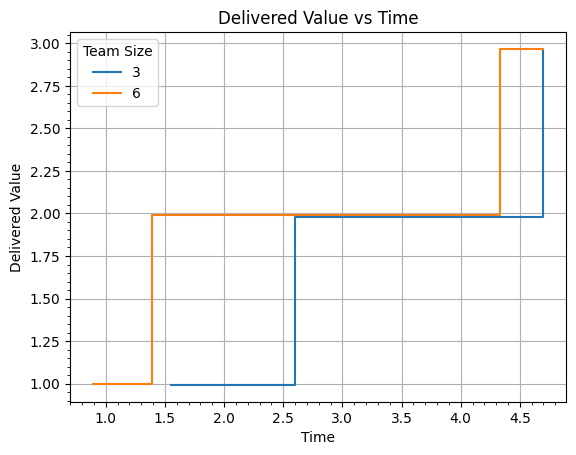

In [24]:

viewer.delivered_value_vs_time(cadence=0)

From the results of the comparatively small simulation used in this tutorial, the plot above shows how the larger team of 6 is able to deliver tasks faster than the smaller team.  This is rather obvious, however the primary benefit of this plot is to show the impact of depreciation.  While the plots above appear to only differ in terms of when value was delivered, a closer examination shows that team of 6 delivered marginally more value due to the faster rate of delivery.   

This difference becomes more evident in simulations with a larger time series and/or tasks with higher depreciation rates.


##### Delivered Value vs Team Size

_delivered_value_vs_team_size_ is similar to the previous example of _delivered_value_vs_time_, but instead shows the impact of team size on value delivery, with series for a sample set of cadences

From the results of the comparatively small simulation used in this tutorial, the plot above shows how the larger team of 6 is able to deliver tasks faster than the smaller team.  This is rather obvious, however the primary benefit of this plot is to show the impact of depreciation.  While the plots above appear to only differ in terms of when value was delivered, a closer examination shows that team of 6 delivered marginally more value due to the faster rate of delivery.   

This difference becomes more evident in simulations with a larger time series and/or tasks with higher depreciation rates.


##### Delivered Value vs Team Size

_delivered_value_vs_team_size_ is similar to the previous example of _delivered_value_vs_time_, but instead shows the impact of team size on value delivery, with series for a sample set of cadences

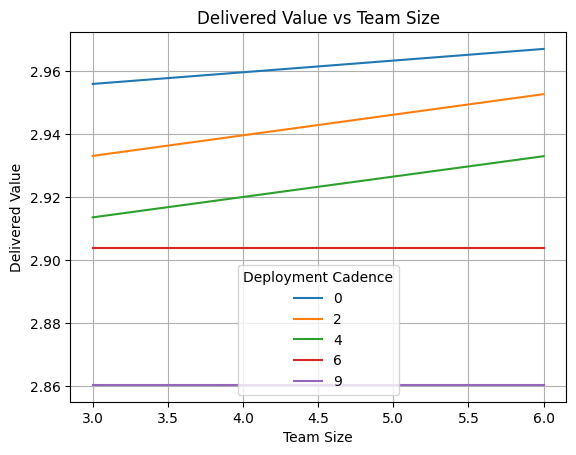

In [25]:
viewer.delivered_value_vs_team_size(cadence_samples=5)

As demonstrated previously, larger cadences reduce the amount of delivered value, while the team size becomes more of a limiting factor once the cadence is frequent enough to keep up with development.